## Data preparation  
Additional test of ABC atlas coronal cuts.

In [1]:
import pandas as pd
import numpy as np
import json
import os
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
download_base = "/data/abc_atlas"
manifest_path = 'releases/20230830/manifest.json'
file = os.path.join(download_base, manifest_path)
with open(file,'rb') as f:
    manifest = json.load(f)
metadata = manifest['file_listing']['MERFISH-C57BL6J-638850']['metadata']
view_directory = os.path.join( download_base, 
                               manifest['directory_listing']['MERFISH-C57BL6J-638850-CCF']['directories']['metadata']['relative_path'], 
                              'views')

In [3]:
view_directory

'/data/abc_atlas/metadata/MERFISH-C57BL6J-638850-CCF/20230830/views'

In [4]:
file = os.path.join( view_directory, 'cell_metadata_with_parcellation_annotation.csv')
cell_joined = pd.read_csv(file,dtype={"cell_label":str})

In [5]:
cell_joined.columns

Index(['cell_label', 'brain_section_label', 'cluster_alias',
       'average_correlation_score', 'feature_matrix_label', 'donor_label',
       'donor_genotype', 'donor_sex', 'x_section', 'y_section', 'z_section',
       'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster',
       'neurotransmitter_color', 'class_color', 'subclass_color',
       'supertype_color', 'cluster_color', 'x_reconstructed',
       'y_reconstructed', 'z_reconstructed', 'parcellation_index', 'x_ccf',
       'y_ccf', 'z_ccf', 'parcellation_organ', 'parcellation_category',
       'parcellation_division', 'parcellation_structure',
       'parcellation_substructure', 'parcellation_organ_color',
       'parcellation_category_color', 'parcellation_division_color',
       'parcellation_structure_color', 'parcellation_substructure_color'],
      dtype='object')

In [6]:
labels = cell_joined['brain_section_label'].unique()
labels

array(['C57BL6J-638850.37', 'C57BL6J-638850.26', 'C57BL6J-638850.25',
       'C57BL6J-638850.13', 'C57BL6J-638850.27', 'C57BL6J-638850.28',
       'C57BL6J-638850.24', 'C57BL6J-638850.05', 'C57BL6J-638850.06',
       'C57BL6J-638850.33', 'C57BL6J-638850.15', 'C57BL6J-638850.16',
       'C57BL6J-638850.17', 'C57BL6J-638850.32', 'C57BL6J-638850.29',
       'C57BL6J-638850.12', 'C57BL6J-638850.30', 'C57BL6J-638850.10',
       'C57BL6J-638850.36', 'C57BL6J-638850.19', 'C57BL6J-638850.43',
       'C57BL6J-638850.40', 'C57BL6J-638850.18', 'C57BL6J-638850.39',
       'C57BL6J-638850.31', 'C57BL6J-638850.08', 'C57BL6J-638850.14',
       'C57BL6J-638850.11', 'C57BL6J-638850.38', 'C57BL6J-638850.42',
       'C57BL6J-638850.35', 'C57BL6J-638850.09', 'C57BL6J-638850.52',
       'C57BL6J-638850.50', 'C57BL6J-638850.47', 'C57BL6J-638850.62',
       'C57BL6J-638850.60', 'C57BL6J-638850.57', 'C57BL6J-638850.49',
       'C57BL6J-638850.55', 'C57BL6J-638850.54', 'C57BL6J-638850.46',
       'C57BL6J-6388

### Filter Isocortex region

In [7]:
region = cell_joined[cell_joined['parcellation_division'] == 'Isocortex']
sections = ['C57BL6J-638850.57', 'C57BL6J-638850.58','C57BL6J-638850.59', 'C57BL6J-638850.60', 'C57BL6J-638850.61']
filtered = region[region['brain_section_label'].isin(sections)]
filtered.to_csv('/data/coro_data.csv')

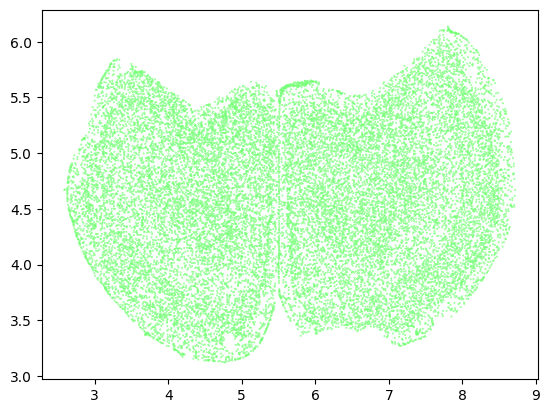

In [8]:
section = filtered[filtered['brain_section_label'].isin(['C57BL6J-638850.60'])]
plt.scatter(section['x_section'], section['y_section'],s=0.5,color=section['parcellation_division_color'],marker='.')

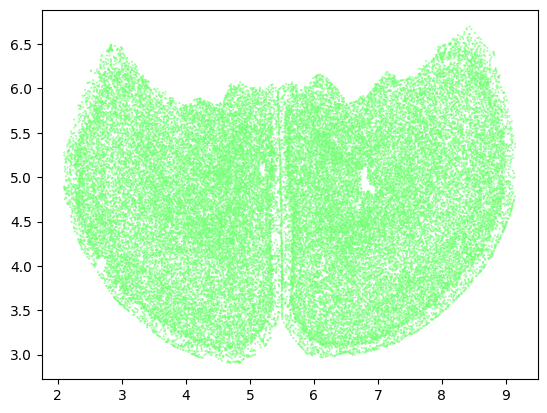

In [9]:
section = filtered[filtered['brain_section_label'].isin(['C57BL6J-638850.57'])]
plt.scatter(section['x_section'], section['y_section'],s=0.5,color=section['parcellation_division_color'],marker='.')

We use the derived dataset **coro_data** for following analysis.

In [10]:
filtered['parcellation_substructure'].unique()

array(['ORBvl2/3', 'ORBl1', 'ORBl6a', 'ORBvl1', 'ORBm1', 'PL6a', 'MOp1',
       'AIv1', 'AId1', 'ORBm2/3', 'ILA1', 'PL1', 'ACAd1', 'MOs1', 'MOs6a',
       'ORBvl5', 'MOs2/3', 'AId5', 'MOp2/3', 'ORBl2/3', 'MOs5', 'MOp5',
       'ORBm5', 'ACAd6a', 'ORBl5', 'AId2/3', 'ACAd2/3', 'AIv6a', 'AId6a',
       'ORBvl6a', 'ILA2/3', 'AIv2/3', 'PL2/3', 'PL5', 'ILA6a', 'ORBm6a',
       'MOp6a', 'ACAd5', 'FRP5', 'ILA5', 'AIv5', 'ORBl6b', 'FRP6a',
       'MOs6b', 'ORBvl6b', 'FRP6b', 'ORBm6b', 'PL6b'], dtype=object)